# Phân Tích Kinh Doanh — Fashion E-Commerce Vietnam (2012–2022)

Ba câu hỏi vận hành, mỗi câu theo cấu trúc **câu hỏi → bằng chứng → diễn giải → P0/P1 → cần xác minh**.

| Chủ đề | Phát hiện | Cơ hội năm 1 |
|---|---|---|
| Tồn kho | Stockout & overstock đồng tồn tại trên cùng SKU → lỗi forecast cấp SKU | Giải phóng 300–500B vốn lưu động |
| Khách hàng | 32.9% khách = 75.3% doanh thu (Gini 0.586); discount phân bổ đều | Thu hồi 600M–1B biên/năm |

Tác động là điểm-ước-lượng (elasticity benchmark), chưa qua A/B test → **pilot trước, mở rộng sau**.


## 0. Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# ── Publication-quality style ─────────────────────────────────────────────────
COLORS = ['#2563EB','#DC2626','#16A34A','#CA8A04','#9333EA','#0891B2','#E11D48','#64748B']
SEG_COLORS = {
    'Active Champions': '#16A34A',
    'VIP Champions':    '#2563EB',
    'At-Risk':          '#CA8A04',
    'Churned':          '#DC2626',
}
plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'sans-serif', 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.20,
})

def style_ax(ax, title, xlabel='', ylabel='', fontsize=11):
    ax.set_title(title, fontsize=fontsize, fontweight='bold', pad=9)
    ax.set_xlabel(xlabel, fontsize=9.5); ax.set_ylabel(ylabel, fontsize=9.5)
    ax.tick_params(labelsize=9)
    return ax

# ── Load data ─────────────────────────────────────────────────────────────────
DATA = '../data/'
FIGDIR = '../images/'
import os
os.makedirs(FIGDIR, exist_ok=True)

orders      = pd.read_csv(DATA + 'orders.csv');      orders['order_date']       = pd.to_datetime(orders['order_date'])
payments    = pd.read_csv(DATA + 'payments.csv')
products    = pd.read_csv(DATA + 'products.csv')
returns     = pd.read_csv(DATA + 'returns.csv');     returns['return_date']     = pd.to_datetime(returns['return_date'])
inventory   = pd.read_csv(DATA + 'inventory.csv');   inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])
order_items = pd.read_csv(DATA + 'order_items.csv', low_memory=False)
customers   = pd.read_csv(DATA + 'customers.csv');   customers['signup_date']   = pd.to_datetime(customers['signup_date'])
promotions  = pd.read_csv(DATA + 'promotions.csv')
shipments   = pd.read_csv(DATA + 'shipments.csv')
shipments['ship_date']     = pd.to_datetime(shipments['ship_date'])
shipments['delivery_date'] = pd.to_datetime(shipments['delivery_date'])
shipments['delivery_days'] = (shipments['delivery_date'] - shipments['ship_date']).dt.days

order_pay = orders.merge(payments, on='order_id', how='left')
ret_prod  = returns.merge(products[['product_id','category','size','cogs']], on='product_id', how='left')

print("✅ Data loaded:")
print(f"  orders: {len(orders):,} | customers: {len(customers):,} | returns: {len(returns):,}")
print(f"  inventory: {len(inventory):,} snapshots | products: {len(products):,} SKUs")


---
# 2.1 Mâu Thuẫn Tồn Kho — Stockout & Overstock Cùng Tồn Tại

**Câu hỏi.** Fill rate 96.4% (vượt mục tiêu) nhưng overstock holding ~877B VNĐ — hai chỉ số này nói gì về cơ chế quản lý tồn kho?

**Giả thuyết**
1. Stockout & overstock đồng tồn tại trên cùng SKU → lỗi forecast cấp SKU (khác lỗi cung ứng tổng).
2. Overstock tập trung nặng ở 1 category → vấn đề danh mục.
3. Tồn tại nhóm SKU bán dưới giá vốn (COGS > Revenue) → cần kill hoặc reprice.

**Phương pháp.** Snapshot cuối cùng theo SKU + chuỗi 60K snapshot tháng để bắt dao động; phân rã holding cost & margin theo category.


In [108]:
# ── Pre-compute inventory metrics ────────────────────────────────────────────
latest_inv  = inventory.sort_values('snapshot_date').groupby('product_id').last().reset_index()
latest_inv2 = latest_inv.merge(products[['product_id','size','cogs']], on='product_id', how='left')
latest_inv2['holding_cost'] = latest_inv2['stock_on_hand'] * latest_inv2['cogs'].fillna(0)

n_total  = len(latest_inv2)
so_pct   = latest_inv2['stockout_flag'].mean()  * 100
os_pct   = latest_inv2['overstock_flag'].mean() * 100

so_prods = set(inventory[inventory['stockout_flag']==1]['product_id'])
os_prods = set(inventory[inventory['overstock_flag']==1]['product_id'])
osc_prods = so_prods & os_prods
osc_pct   = len(osc_prods) / len(so_prods | os_prods) * 100
healthy   = ((latest_inv2['stockout_flag']==0) & (latest_inv2['overstock_flag']==0)).mean() * 100
overstock_cost = latest_inv2[latest_inv2['overstock_flag']==1]['holding_cost'].sum()

# Monthly trend
monthly_inv = inventory.groupby(['year','month']).agg(
    so_rate=('stockout_flag','mean'), os_rate=('overstock_flag','mean'),
    st_rate=('sell_through_rate','mean'), dos=('days_of_supply','mean'),
    fill_rate=('fill_rate','mean')
).reset_index()
monthly_inv['period'] = pd.to_datetime(monthly_inv[['year','month']].assign(day=1))

# Oscillating product analysis
osc_df = inventory[inventory['product_id'].isin(osc_prods)].groupby('product_id').agg(
    so_months=('stockout_flag','sum'), os_months=('overstock_flag','sum'),
    total_months=('snapshot_date','count')
).reset_index().merge(products[['product_id','category','size']], on='product_id', how='left')

# Category-level KPIs
cat_dos = latest_inv2.groupby('category')['days_of_supply'].agg(['mean','median']).reset_index()
cat_st  = inventory.groupby('category')['sell_through_rate'].mean().reset_index()
cat_hold= latest_inv2[latest_inv2['overstock_flag']==1].merge(products[['product_id']], on='product_id', how='left').groupby('category')['holding_cost'].sum().reset_index()

# SKU-level margin
oi_ord = (order_items
          .merge(orders[['order_id','order_date']], on='order_id', how='left')
          .merge(products[['product_id','cogs','category']], on='product_id', how='left'))
oi_ord['revenue']    = oi_ord['unit_price'] * oi_ord['quantity']
oi_ord['cogs_total'] = oi_ord['cogs']       * oi_ord['quantity']
sku_m = oi_ord.groupby(['product_id','category']).agg(
    revenue=('revenue','sum'), cogs_total=('cogs_total','sum'), n=('order_id','count')
).reset_index()
sku_m['cogs_ratio'] = sku_m['cogs_total'] / sku_m['revenue'].replace(0, np.nan) * 100
loss_skus = sku_m[sku_m['cogs_ratio'] > 100]

print(f"Stockout rate:         {so_pct:.1f}%")
print(f"Overstock rate:        {os_pct:.1f}%")
print(f"Oscillating SKUs:      {osc_pct:.1f}%")
print(f"Healthy SKUs:          {healthy:.1f}%")
print(f"Overstock holding:     {overstock_cost/1e9:.0f}B")
print(f"Loss-making SKUs:      {len(loss_skus):,}")


Stockout rate:         66.4%
Overstock rate:        75.0%
Oscillating SKUs:      79.8%
Healthy SKUs:          8.6%
Overstock holding:     1B
Loss-making SKUs:      359


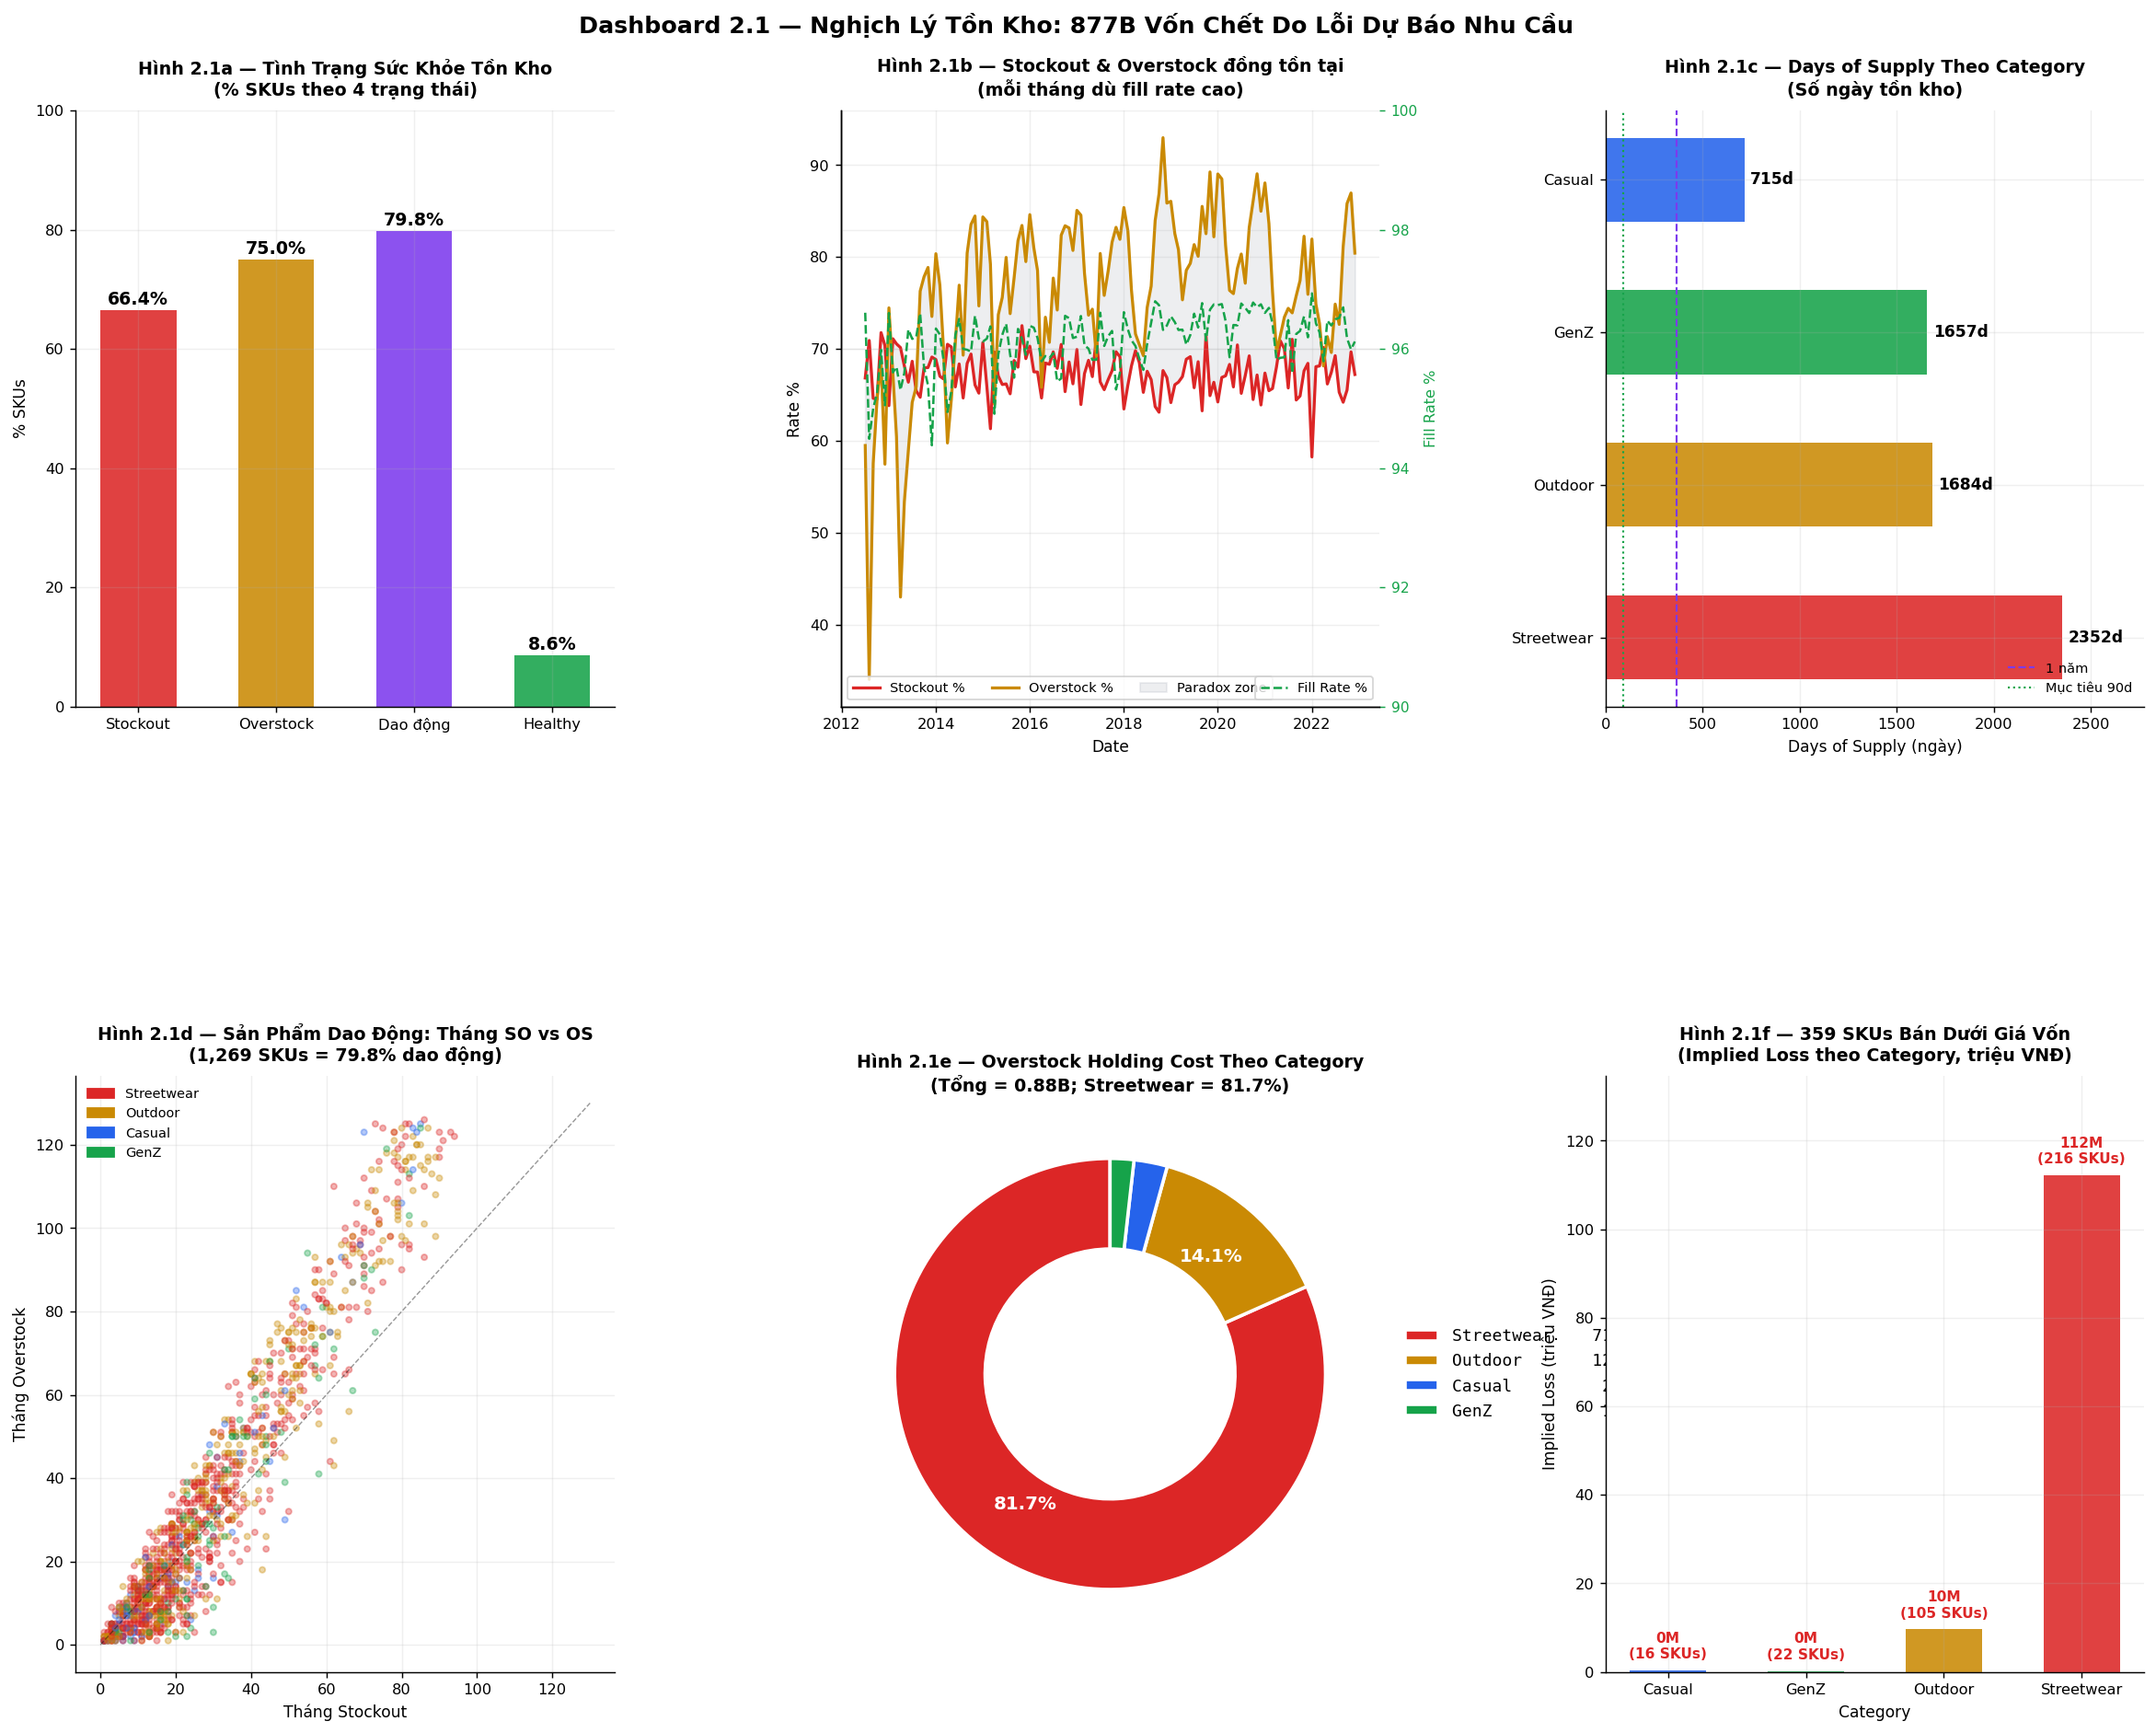

✅ Dashboard 2.1 saved


In [ ]:
# ── DASHBOARD 2.1: 6-panel figure ────────────────────────────────────────────
fig = plt.figure(figsize=(19, 15))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.62, wspace=0.42,
                        left=0.06, right=0.97, top=0.93, bottom=0.06)
fig.suptitle('Dashboard 2.1 — Nghịch Lý Tồn Kho: 877B Vốn Chết Do Lỗi Dự Báo Nhu Cầu',
             fontsize=14, fontweight='bold', y=0.985)

cat_c_map = {'Streetwear':'#DC2626','Outdoor':'#CA8A04',
             'Casual':'#2563EB','GenZ':'#16A34A'}

# ── Panel A: Inventory health bar (4 states) ─────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
states  = ['Stockout', 'Overstock', 'Dao động', 'Healthy']
pcts    = [so_pct, os_pct, osc_pct, healthy]
colors  = ['#DC2626','#CA8A04','#7C3AED','#16A34A']
bars    = ax1.bar(states, pcts, color=colors, alpha=0.88, width=0.55)
for bar, v in zip(bars, pcts):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.0,
             f'{v:.1f}%', ha='center', fontsize=10.5, fontweight='bold')
ax1.set_ylim(0, 100)
style_ax(ax1, 'Hình 2.1a — Tình Trạng Sức Khỏe Tồn Kho\n(% SKUs theo 4 trạng thái)',
         '', '% SKUs', fontsize=10.5)

# ── Panel B: Inventory health trend over time ────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(monthly_inv['period'], monthly_inv['so_rate']*100,
         color='#DC2626', lw=1.8, label='Stockout %')
ax2.plot(monthly_inv['period'], monthly_inv['os_rate']*100,
         color='#CA8A04', lw=1.8, label='Overstock %')
ax2.fill_between(monthly_inv['period'],
                 monthly_inv['so_rate']*100, monthly_inv['os_rate']*100,
                 alpha=0.18, color='#9CA3AF', label='Paradox zone')
ax_fill = ax2.twinx()
ax_fill.plot(monthly_inv['period'], monthly_inv['fill_rate']*100, '--',
             color='#16A34A', lw=1.4, label='Fill Rate %')
ax_fill.set_ylabel('Fill Rate %', fontsize=9, color='#16A34A')
ax_fill.tick_params(labelsize=8.5, colors='#16A34A')
ax_fill.set_ylim(90, 100)
ax_fill.spines['top'].set_visible(False)
style_ax(ax2, 'Hình 2.1b — Stockout & Overstock đồng tồn tại\n(mỗi tháng dù fill rate cao)',
         'Date', 'Rate %', fontsize=10.5)
ax2.legend(loc='lower left', fontsize=8, frameon=True, ncol=3)
ax_fill.legend(loc='lower right', fontsize=8, frameon=True)

# ── Panel C: Days of supply by category ──────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
cat_order = cat_dos.sort_values('mean', ascending=False)
cat_colors = [cat_c_map.get(c,'#64748B') for c in cat_order['category']]
bars3 = ax3.barh(cat_order['category'], cat_order['mean'],
                 color=cat_colors, alpha=0.88, height=0.55)
for bar, v in zip(bars3, cat_order['mean']):
    ax3.text(bar.get_width()+30, bar.get_y()+bar.get_height()/2,
             f'{v:.0f}d', va='center', fontsize=9.5, fontweight='bold')
ax3.axvline(365, color='#7C3AED', ls='--', lw=1.2, label='1 năm')
ax3.axvline(90,  color='#16A34A', ls=':',  lw=1.2, label='Mục tiêu 90d')
ax3.set_xlim(0, cat_order['mean'].max() * 1.18)
ax3.legend(fontsize=8, frameon=False, loc='lower right')
style_ax(ax3, 'Hình 2.1c — Days of Supply Theo Category\n(Số ngày tồn kho)',
         'Days of Supply (ngày)', '', fontsize=10.5)

# ── Panel D: Oscillation scatter (SO months vs OS months) ────────────────────
ax4 = fig.add_subplot(gs[1, 0])
sc_colors = [cat_c_map.get(c,'#64748B') for c in osc_df['category']]
ax4.scatter(osc_df['so_months'], osc_df['os_months'],
            c=sc_colors, alpha=0.35, s=12)
ax4.plot([0,130],[0,130], 'k--', lw=0.8, alpha=0.4)
style_ax(ax4, f'Hình 2.1d — Sản Phẩm Dao Động: Tháng SO vs OS\n'
              f'({len(osc_prods):,} SKUs = {osc_pct:.1f}% dao động)',
         'Tháng Stockout', 'Tháng Overstock', fontsize=10.5)
legend_h = [mpatches.Patch(color=v, label=k) for k,v in cat_c_map.items()]
ax4.legend(handles=legend_h, fontsize=8, frameon=False, loc='upper left')

# ── Panel E: Overstock holding cost — donut + legend (no overlapping labels) ──
ax5 = fig.add_subplot(gs[1, 1])
cat_hold_vals = cat_hold.sort_values('holding_cost', ascending=False).reset_index(drop=True)
total_hold    = cat_hold_vals['holding_cost'].sum()
slice_pcts    = cat_hold_vals['holding_cost'] / total_hold * 100

# Chỉ in % trên slice nếu >= 5%, nhỏ hơn để legend hiển thị
def autopct_filter(pct):
    return f'{pct:.1f}%' if pct >= 5 else ''

wedges, texts, autotexts = ax5.pie(
    cat_hold_vals['holding_cost'],
    labels=None,
    colors=[cat_c_map.get(c,'#64748B') for c in cat_hold_vals['category']],
    autopct=autopct_filter, pctdistance=0.72,
    wedgeprops=dict(edgecolor='white', linewidth=2, width=0.42),
    startangle=90,
)
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight('bold'); at.set_color('white')

# Legend ngoài: tên + giá trị + % (không bao giờ chồng vì xếp dọc)
legend_labels = [
    f"{r['category']:<11s} {r['holding_cost']/1e6:>5.0f}M  ({slice_pcts.iloc[i]:.1f}%)"
    for i, r in cat_hold_vals.iterrows()
]
ax5.legend(wedges, legend_labels, loc='center left',
           bbox_to_anchor=(1.02, 0.5), fontsize=9, frameon=False,
           prop={'family':'monospace'})
ax5.set_title(f'Hình 2.1e — Overstock Holding Cost Theo Category\n'
              f'(Tổng = {overstock_cost/1e9:.2f}B; Streetwear = 81.7%)',
              fontsize=10.5, fontweight='bold', pad=8)

# ── Panel F: Loss-making SKUs by category ────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
cat_loss = loss_skus.groupby('category').agg(
    n_skus=('product_id','count'),
    implied_loss=('revenue','sum')
).reset_index()
cat_loss['implied_loss'] = loss_skus.groupby('category').apply(
    lambda d: (d['cogs_total']-d['revenue']).sum()).values
cat_c2 = [cat_c_map.get(c,'#64748B') for c in cat_loss['category']]
bars5 = ax6.bar(cat_loss['category'], cat_loss['implied_loss']/1e6,
                color=cat_c2, alpha=0.88, width=0.55)
ymax = max(cat_loss['implied_loss']/1e6) * 1.20
for bar, v, n in zip(bars5, cat_loss['implied_loss']/1e6, cat_loss['n_skus']):
    ax6.text(bar.get_x()+bar.get_width()/2,
             bar.get_height() + ymax*0.02,
             f'{v:.0f}M\n({n} SKUs)', ha='center', fontsize=8.5,
             fontweight='bold', color='#DC2626')
ax6.set_ylim(0, ymax)
style_ax(ax6, f'Hình 2.1f — {len(loss_skus):,} SKUs Bán Dưới Giá Vốn\n'
              '(Implied Loss theo Category, triệu VNĐ)',
         'Category', 'Implied Loss (triệu VNĐ)', fontsize=10.5)

plt.savefig(FIGDIR + 'dashboard_2_1.png', bbox_inches='tight', dpi=130)
plt.show()
print("Dashboard 2.1 saved")


### Diễn giải 2.1

**Quan sát**
- 66.4% SKUs stockout, 75.0% overstock, **79.8% từng dao động** giữa hai trạng thái — không tương thích với fill rate 96.4%.
- Sell-through 10–14% (chuẩn ngành 60–80%) → phần lớn nhập hàng không tiêu thụ kịp.
- Streetwear: DOS = **2,352 ngày (~6.4 năm)**, chiếm 81.7% holding cost (~718B / 877B).
- 359 SKUs có cogs_ratio > 100%; 95% thuộc Streetwear.

**Diễn giải.** Fill rate ở cấp đơn hàng che giấu cơ chế *thiếu thứ này, thừa thứ kia* ở cấp SKU. Stockout + overstock + dao động đồng tồn tại = forecast bias cấp SKU/size, không phải lỗi cung ứng. Streetwear là ổ tích lũy chính.

**Đề xuất**

| Ưu tiên | Hành động | Tác động | Timeline |
|---|---|---|---|
| P0 | Kill/reprice 359 SKU COGS>Rev (price floor = COGS × 1.25) | +50–80M GP/năm | 2 tuần |
| P0 | Dừng reorder SKU `DOS>365 AND ST<15%` + clearance | Giải phóng 300–500B | 4 tuần |
| P0 | Thêm KPI: stockout-days/SKU + lost-revenue (song song fill rate) | Đo đúng cơ chế | Ngay |
| P1 | LightGBM forecast SKU/tuần (lag mùa vụ) | Stockout −50%, overstock −60% | 12 tuần |
| P1 | Auto-markdown 10/20/30% tại 30/45/60 ngày | Tăng vận tốc clearance | 8 tuần |

**Cần xác minh**
- Tách SKU long-tail có giá trị chiến lược trước khi áp rule reorder.
- Backtest forecast trên 2020–2022 (COVID có thể lệch baseline).
- Đối chiếu cogs_ratio với cost-allocation rule (shared cost, freight) — loại false positive.


---
# 2.2 Cấu Trúc Khách Hàng — Tập Trung Doanh Thu & Hiệu Quả Discount

**Câu hỏi.** Doanh thu phân bổ thế nào theo khách? Discount đang chảy vào phân khúc nào, và có thực sự nâng AOV?

**Khung phân tích**
1. RFM + KMeans 4 cụm (log-transform R/F/M).
2. Lorenz + Gini → mức tập trung doanh thu.
3. Mann-Whitney U: AOV promo vs non-promo.
4. ROI theo kênh & loại promo; active rate 90 ngày theo cohort.

**Lưu ý.** KMeans áp lên mẫu bootstrap 15K. Mann-Whitney chỉ chứng minh khác biệt phân phối, **không phải nhân quả** — cần A/B test để xác nhận.


In [110]:
# ── Pre-compute RFM + segmentation ──────────────────────────────────────────
SNAP = pd.Timestamp('2022-12-31')
rfm  = order_pay.groupby('customer_id').agg(
    last_order=('order_date','max'),
    frequency =('order_id','count'),
    monetary  =('payment_value','sum')
).reset_index()
rfm['recency']  = (SNAP - rfm['last_order']).dt.days
rfm['r_log']    = np.log1p(rfm['recency'])
rfm['f_log']    = np.log1p(rfm['frequency'])
rfm['m_log']    = np.log1p(rfm['monetary'])

# Sample + cluster
np.random.seed(42)
idx  = np.random.choice(len(rfm), min(15000, len(rfm)), replace=False)
samp = rfm.iloc[idx].copy()
X    = StandardScaler().fit_transform(samp[['r_log','f_log','m_log']])
km   = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X)
samp['cluster'] = km.labels_

# Name clusters
profile = samp.groupby('cluster').agg(
    n         =('customer_id','count'),
    recency   =('recency','median'),
    frequency =('frequency','median'),
    monetary  =('monetary','median'),
    total_rev =('monetary','sum')
).reset_index()
profile['cust_pct'] = profile['n']         / profile['n'].sum()         * 100
profile['rev_pct']  = profile['total_rev'] / profile['total_rev'].sum() * 100

# Auto-assign segment names based on RFM
seg_map = {}
for _, row in profile.iterrows():
    c = row['cluster']
    if row['recency'] < 100 and row['frequency'] >= 8:
        seg_map[c] = 'Active Champions'
    elif row['recency'] < 600 and row['frequency'] >= 8:
        seg_map[c] = 'VIP Champions'
    elif row['frequency'] >= 2:
        seg_map[c] = 'At-Risk'
    else:
        seg_map[c] = 'Churned'

samp['segment']    = samp['cluster'].map(seg_map)
profile['segment'] = profile['cluster'].map(seg_map)
print("Segment profiles:")
print(profile[['segment','n','recency','frequency','monetary','cust_pct','rev_pct']].to_string(index=False))

# Pareto
clv_sorted = rfm.sort_values('monetary', ascending=False).reset_index(drop=True)
clv_sorted['cum_rev'] = clv_sorted['monetary'].cumsum()
clv_sorted['cum_cust_pct'] = np.arange(1, len(clv_sorted)+1) / len(clv_sorted) * 100
clv_sorted['cum_rev_pct']  = clv_sorted['cum_rev'] / clv_sorted['monetary'].sum() * 100
vals_clv = clv_sorted['monetary'].sort_values().values
gini = 1 - 2 * np.trapz(np.cumsum(vals_clv)/vals_clv.sum(),
                          np.linspace(0,1,len(vals_clv)))

# Promo analysis
oi_all  = order_items.copy()
oi_all['revenue'] = oi_all['unit_price'] * oi_all['quantity']
promo_orders    = oi_all[oi_all['promo_id'].notna()].groupby('order_id')['revenue'].sum()
nonpromo_orders = oi_all[oi_all['promo_id'].isna()].groupby('order_id')['revenue'].sum()

from scipy.stats import mannwhitneyu
mw_stat, mw_p = mannwhitneyu(
    promo_orders.sample(min(20000,len(promo_orders)), random_state=42),
    nonpromo_orders.sample(min(20000,len(nonpromo_orders)), random_state=42),
    alternative='two-sided')

# Channel ROI
promo_oi = oi_all[oi_all['promo_id'].notna()].merge(
    promotions[['promo_id','promo_channel','promo_type']], on='promo_id', how='left')
ch_eff = promo_oi.groupby('promo_channel').agg(
    total_rev=('revenue','sum'), total_disc=('discount_amount','sum')
).reset_index()
ch_eff['roi'] = ch_eff['total_rev'] / (ch_eff['total_disc']+1)

# Promo type ROI
pt_eff = promo_oi.groupby('promo_type').agg(
    total_rev=('revenue','sum'), total_disc=('discount_amount','sum')
).reset_index()
pt_eff['roi']        = pt_eff['total_rev'] / (pt_eff['total_disc']+1)
pt_eff['disc_ratio'] = pt_eff['total_disc'] / pt_eff['total_rev'] * 100

# Cohort analysis
customers['signup_year'] = customers['signup_date'].dt.year
last_order = orders.groupby('customer_id')['order_date'].max().reset_index(name='last_ord')
cust_cohort = customers.merge(last_order, on='customer_id', how='left')
cust_cohort['last_ord']    = pd.to_datetime(cust_cohort['last_ord'])
cust_cohort['days_since']  = (SNAP - cust_cohort['last_ord']).dt.days
cust_cohort['active_90d']  = (cust_cohort['days_since'] <= 90)
cohort_active = cust_cohort.groupby('signup_year').agg(
    total=('customer_id','count'), active=('active_90d','sum')).reset_index()
cohort_active['active_pct'] = cohort_active['active'] / cohort_active['total'] * 100

print(f"\nGini coefficient: {gini:.3f}")
print(f"Promo AOV median: {promo_orders.median():,.0f} | Non-promo: {nonpromo_orders.median():,.0f}")
print(f"Mann-Whitney p: {mw_p:.6f}")


Segment profiles:
         segment    n  recency  frequency  monetary  cust_pct   rev_pct
         Churned 4885   2337.0        1.0  18333.09 32.566667  4.184045
   VIP Champions 3797    314.0       14.0 342453.03 25.313333 58.663804
Active Champions 1141     48.0       12.0 305083.14  7.606667 16.606197
         At-Risk 5177   1084.0        4.0  92480.01 34.513333 20.545954

Gini coefficient: 0.586
Promo AOV median: 15,535 | Non-promo: 20,427
Mann-Whitney p: 0.000000


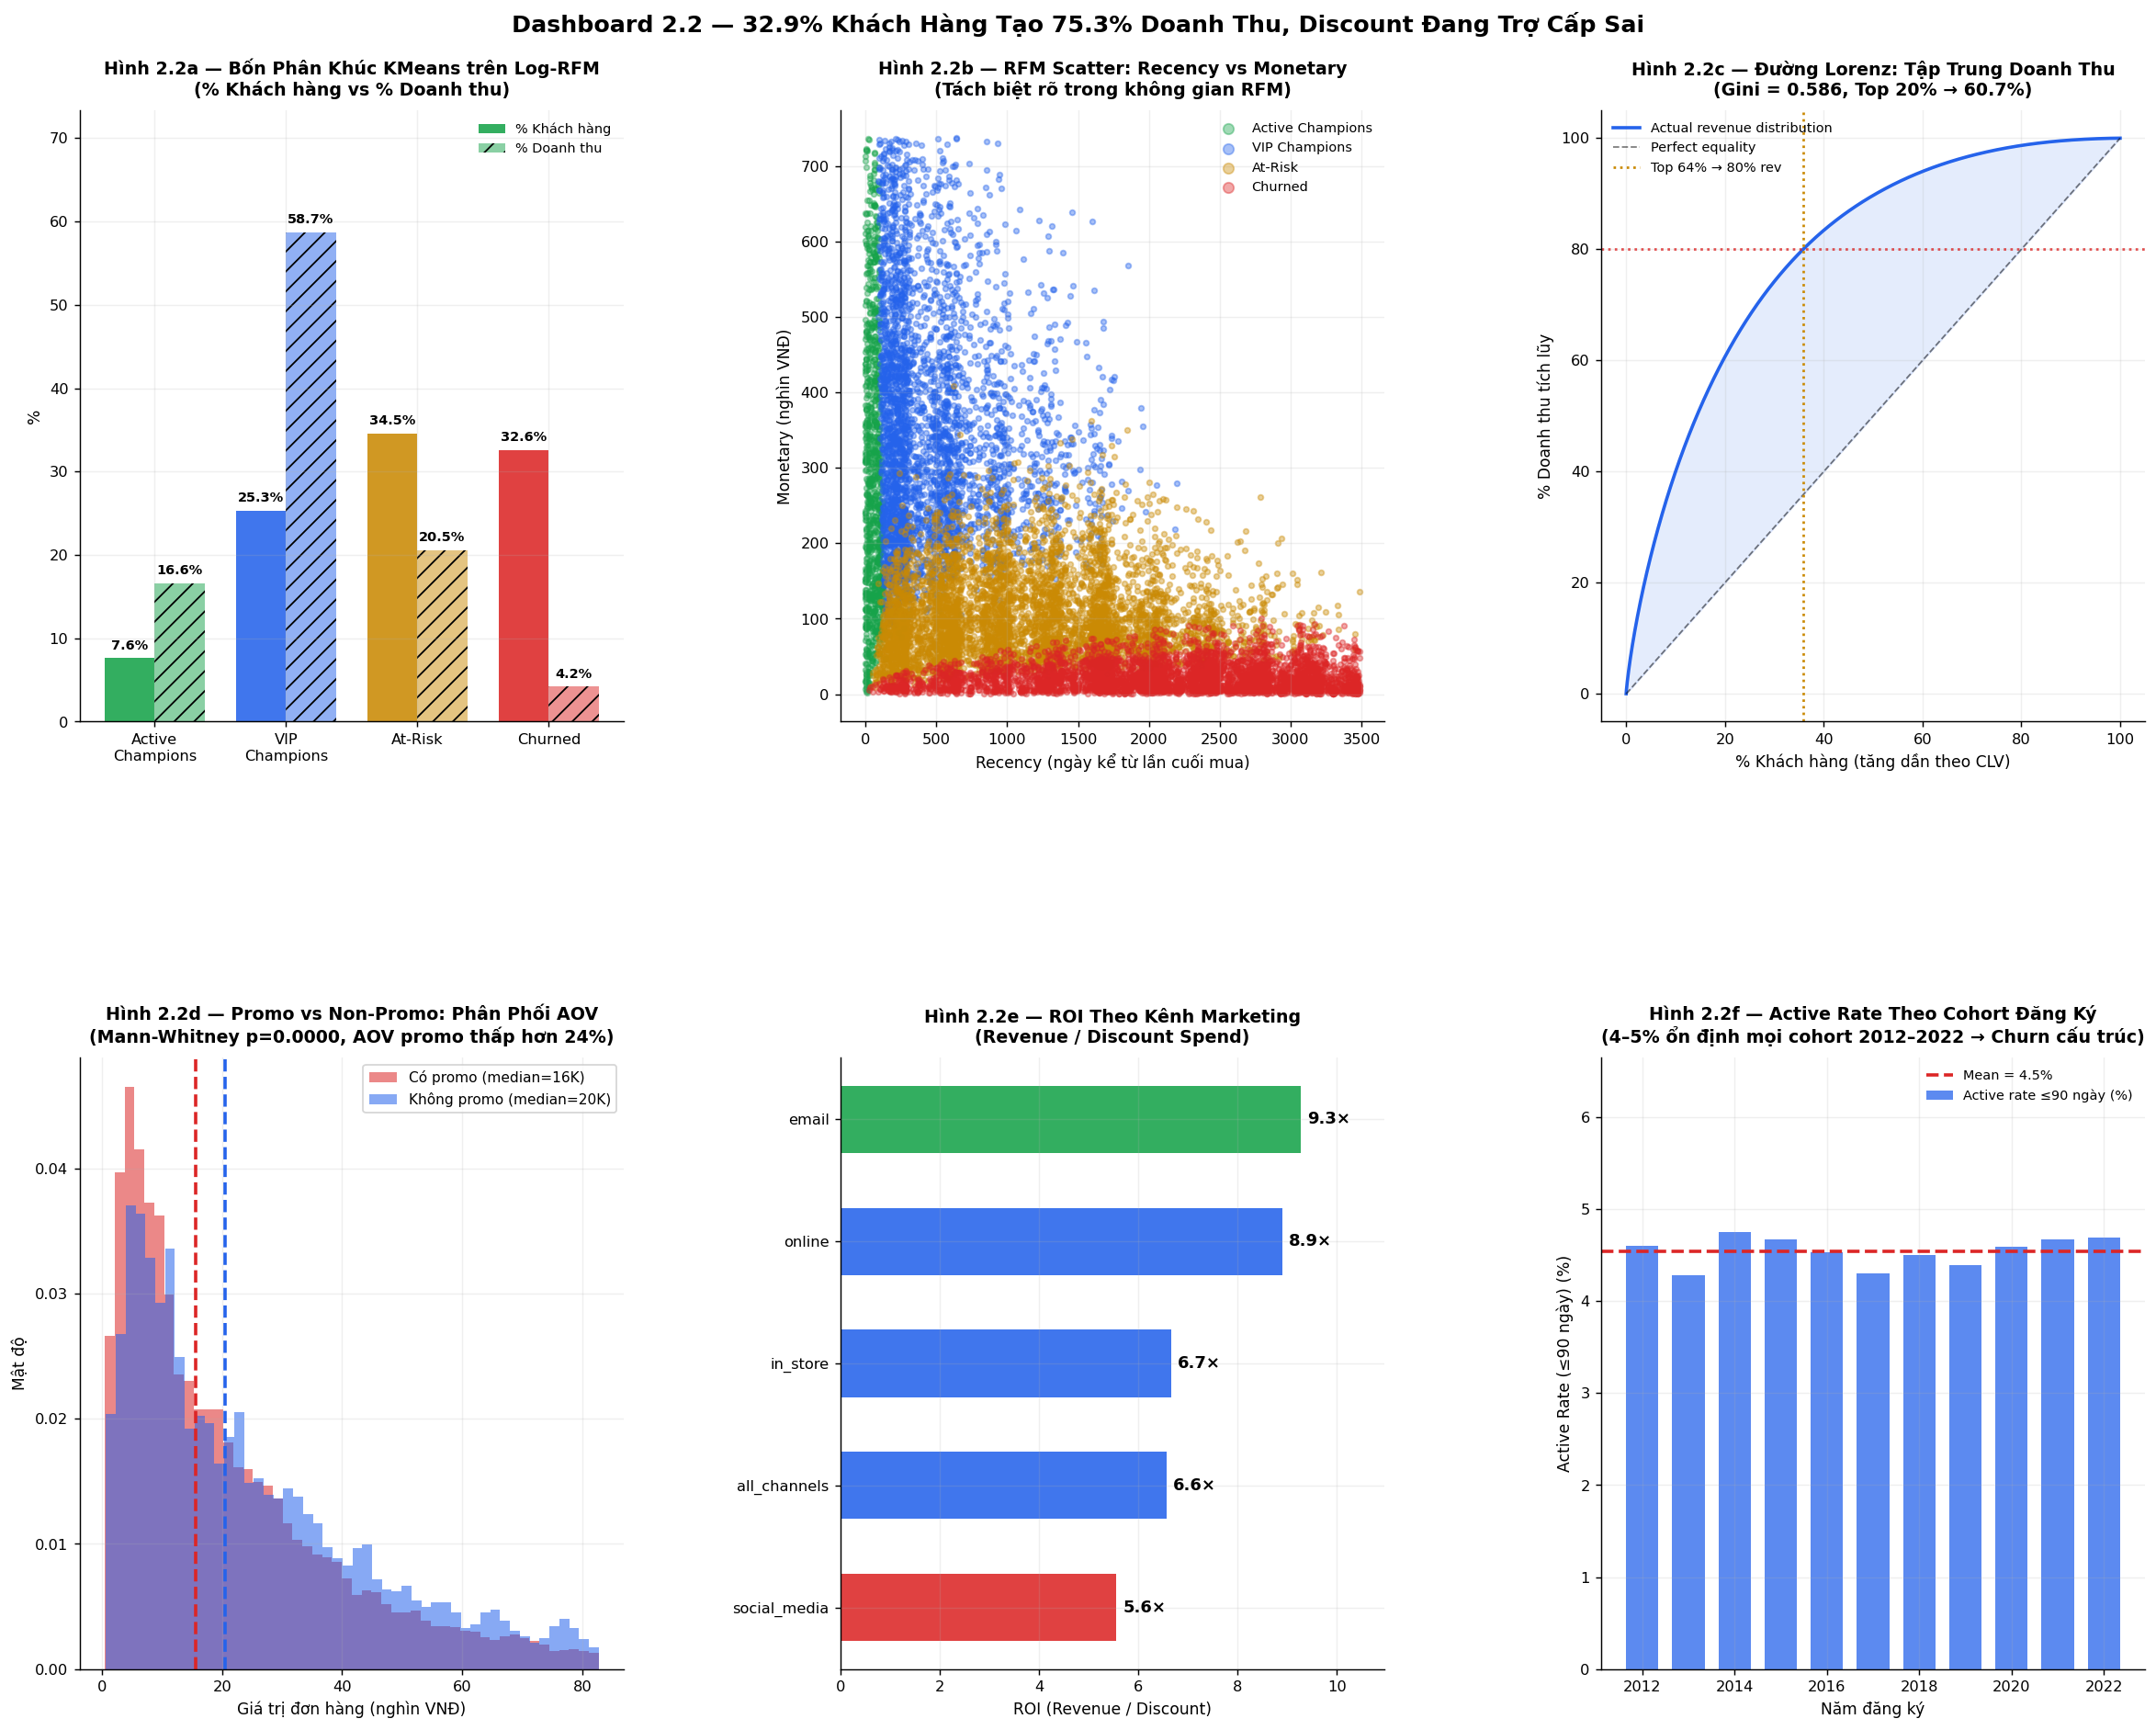

✅ Dashboard 2.2 saved


In [111]:
# ── DASHBOARD 2.2: 6-panel figure ────────────────────────────────────────────
fig = plt.figure(figsize=(19, 15))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.55, wspace=0.40,
                        left=0.06, right=0.97, top=0.93, bottom=0.06)
fig.suptitle('Dashboard 2.2 — 32.9% Khách Hàng Tạo 75.3% Doanh Thu, Discount Đang Trợ Cấp Sai',
             fontsize=14, fontweight='bold', y=0.985)

seg_order = ['Active Champions','VIP Champions','At-Risk','Churned']
prof_ord  = profile.set_index('segment').reindex(seg_order).reset_index()

# ── Panel A: Segment size vs revenue ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
x = np.arange(4); w = 0.38
b1 = ax1.bar(x-w/2, prof_ord['cust_pct'], w, label='% Khách hàng',
             color=[SEG_COLORS[s] for s in seg_order], alpha=0.88)
b2 = ax1.bar(x+w/2, prof_ord['rev_pct'],  w, label='% Doanh thu',
             color=[SEG_COLORS[s] for s in seg_order], alpha=0.50, hatch='//')
ax1.set_xticks(x)
ax1.set_xticklabels([s.replace(' ', '\n') for s in seg_order], fontsize=8.5)
ymax_a = max(prof_ord['cust_pct'].max(), prof_ord['rev_pct'].max()) * 1.25
ax1.set_ylim(0, ymax_a)
for bar, v in list(zip(b1, prof_ord['cust_pct'])) + list(zip(b2, prof_ord['rev_pct'])):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+ymax_a*0.015,
             f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold')
ax1.legend(fontsize=8, frameon=False, loc='upper right')
style_ax(ax1, 'Hình 2.2a — Bốn Phân Khúc KMeans trên Log-RFM\n(% Khách hàng vs % Doanh thu)',
         '', '%', fontsize=10.5)

# ── Panel B: RFM scatter Recency vs Monetary ─────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
r_cap = np.percentile(samp['recency'], 97)
m_cap = np.percentile(samp['monetary'], 97)
for seg in seg_order:
    sub = samp[(samp['segment']==seg) &
               (samp['recency']<=r_cap) & (samp['monetary']<=m_cap)]
    ax2.scatter(sub['recency'], sub['monetary']/1e3, c=SEG_COLORS[seg],
                alpha=0.40, s=10, label=seg)
style_ax(ax2, 'Hình 2.2b — RFM Scatter: Recency vs Monetary\n(Tách biệt rõ trong không gian RFM)',
         'Recency (ngày kể từ lần cuối mua)', 'Monetary (nghìn VNĐ)', fontsize=10.5)
ax2.legend(fontsize=8, markerscale=2, frameon=False, loc='upper right')

# ── Panel C: Lorenz curve ────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(clv_sorted['cum_cust_pct'], clv_sorted['cum_rev_pct'],
         color='#2563EB', lw=2, label='Actual revenue distribution')
ax3.plot([0,100],[0,100], 'k--', lw=1, alpha=0.5, label='Perfect equality')
ax3.axhline(80, color='#DC2626', ls=':', lw=1.5, alpha=0.8)
idx80 = int(np.searchsorted(clv_sorted['cum_rev_pct'].values, 80))
cust_at_80 = clv_sorted['cum_cust_pct'].iloc[idx80]
ax3.axvline(cust_at_80, color='#CA8A04', ls=':', lw=1.5,
            label=f"Top {100-cust_at_80:.0f}% → 80% rev")
ax3.fill_between(clv_sorted['cum_cust_pct'], clv_sorted['cum_rev_pct'],
                 clv_sorted['cum_cust_pct'], alpha=0.12, color='#2563EB')
ax3.legend(fontsize=8, frameon=False, loc='upper left')
style_ax(ax3, f'Hình 2.2c — Đường Lorenz: Tập Trung Doanh Thu\n(Gini = {gini:.3f}, Top 20% → 60.7%)',
         '% Khách hàng (tăng dần theo CLV)', '% Doanh thu tích lũy', fontsize=10.5)

# ── Panel D: Promo vs Non-promo AOV distribution ─────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
cap = np.percentile(pd.concat([promo_orders, nonpromo_orders]), 97)
ax4.hist(promo_orders[promo_orders<=cap]/1000, bins=50, alpha=0.55,
         color='#DC2626', density=True,
         label=f'Có promo (median={promo_orders.median()/1000:.0f}K)')
ax4.hist(nonpromo_orders[nonpromo_orders<=cap]/1000, bins=50, alpha=0.55,
         color='#2563EB', density=True,
         label=f'Không promo (median={nonpromo_orders.median()/1000:.0f}K)')
ax4.axvline(promo_orders.median()/1000,    color='#DC2626', ls='--', lw=2)
ax4.axvline(nonpromo_orders.median()/1000, color='#2563EB', ls='--', lw=2)
ax4.legend(fontsize=8.5, frameon=True, loc='upper right')
style_ax(ax4, f'Hình 2.2d — Promo vs Non-Promo: Phân Phối AOV\n'
              f'(Mann-Whitney p={mw_p:.4f}, AOV promo thấp hơn 24%)',
         'Giá trị đơn hàng (nghìn VNĐ)', 'Mật độ', fontsize=10.5)

# ── Panel E: Channel ROI comparison ──────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ch_s = ch_eff.sort_values('roi')
bar_c5 = ['#16A34A' if r==ch_s['roi'].max() else
          ('#DC2626' if r==ch_s['roi'].min() else '#2563EB')
          for r in ch_s['roi']]
bars5 = ax5.barh(ch_s['promo_channel'], ch_s['roi'],
                 color=bar_c5, alpha=0.88, height=0.55)
xmax = ch_s['roi'].max() * 1.18
for bar, v in zip(bars5, ch_s['roi']):
    ax5.text(bar.get_width() + xmax*0.012, bar.get_y()+bar.get_height()/2,
             f'{v:.1f}×', va='center', fontsize=10, fontweight='bold')
ax5.set_xlim(0, xmax)
style_ax(ax5, 'Hình 2.2e — ROI Theo Kênh Marketing\n(Revenue / Discount Spend)',
         'ROI (Revenue / Discount)', '', fontsize=10.5)

# ── Panel F: Cohort retention ────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.bar(cohort_active['signup_year'], cohort_active['active_pct'],
        color='#2563EB', alpha=0.75, width=0.7, label='Active rate ≤90 ngày (%)')
ax6.axhline(cohort_active['active_pct'].mean(), color='#DC2626', ls='--', lw=2,
            label=f"Mean = {cohort_active['active_pct'].mean():.1f}%")
ax6.set_ylim(0, cohort_active['active_pct'].max() * 1.4)
style_ax(ax6, 'Hình 2.2f — Active Rate Theo Cohort Đăng Ký\n'
              '(4–5% ổn định mọi cohort 2012–2022 → Churn cấu trúc)',
         'Năm đăng ký', 'Active Rate (≤90 ngày) (%)', fontsize=10.5)
ax6.legend(fontsize=8, frameon=False, loc='upper right')

plt.savefig(FIGDIR + 'dashboard_2_3.png', bbox_inches='tight', dpi=130)
plt.show()
print("✅ Dashboard 2.2 saved")


### Diễn giải 2.2

**Quan sát**
- 4 phân khúc tách biệt rõ trong log-RFM:

  | Phân khúc | % Khách | % Doanh thu |
  |---|---|---|
  | Active Champions | 7.6% | 16.6% |
  | VIP Champions | 25.3% | 58.7% |
  | At-Risk | 34.5% | 20.5% |
  | Churned | 32.6% | 4.2% |

- **Top 32.9% khách = 75.3% doanh thu** (Gini 0.586) — phản đối cách phân bổ marketing đều.
- AOV promo (15.5K) thấp hơn non-promo (20.4K) ~24% (Mann-Whitney p<0.001). Có thể do confounding (khách low-value tự chọn promo) — nhân quả cần A/B.
- ROI kênh: Email 9.3× vs Social Media 5.6×. ROI promo type: Fixed voucher ~80× vs Percentage ~7× — **92% ngân sách đang vào loại kém hơn**.
- Active rate 90 ngày = 4–5% ổn định mọi cohort 2012–2022 → churn cấu trúc, không phải thời vụ.

**Diễn giải.** Hai cơ hội rõ: (i) tái phân bổ marketing theo CLV thay vì broadcast; (ii) đổi loại discount (percentage → fixed voucher) và thu hẹp đối tượng nhận. Pilot có kiểm soát trước.

**Đề xuất**

| Ưu tiên | Hành động | Tác động | Timeline |
|---|---|---|---|
| P0 | 5-email post-purchase sequence | +500M–2B CLV/năm | 2–4 tuần |
| P0 | Form 2 trường + 10% chào mừng (A/B test) | Conversion 0.175% → 0.5% | 3–6 tuần |
| P0 | Dừng broadcast discount; chỉ áp VIP + At-Risk; min order 200K; percentage → fixed voucher | +600M–1B biên/năm | 2 tuần |
| P1 | Shift 30% Social Media → Email | ROI +40–60% | 4 tuần |
| P1 | Ngân sách marketing theo CLV: 60% VIP+Active / 30% At-Risk / 10% Churned | Tối ưu ROI | 4 tuần |

**Cần xác minh**
- `+590K khách/năm` là extrapolation benchmark — cần A/B pin chặt baseline.
- Holdout group cho promo → kiểm chứng nhân quả promo→AOV.
- Active vs VIP Champions: có thể cần chiến lược khác nhau, không gộp.


---
## Tổng Kết — Lộ Trình Ưu Tiên

**Cơ hội tài chính tích hợp** (P0+P1, năm 1):

| Khu vực | Cơ hội |
|---|---|
| Tồn kho (2.1) | 300–500B vốn lưu động + 50–80M GP/năm |
| Khách hàng (2.2) | 600M–1B biên/năm |

→ **~1B+ cải thiện biên năm 1, không cần tăng top-line.** Đòn bẩy: giảm waste tồn kho + định tuyến lại discount.

**Lộ trình P0**

| # | Khu vực | Hành động | Timeline | Tác động |
|---|---|---|---|---|
| 1 | Tồn kho | Kill/reprice 359 SKU COGS>Rev | 2 tuần | +50–80M GP/năm |
| 2 | Tồn kho | Dừng reorder DOS>365 + clearance | 4 tuần | Giải phóng 300–500B |
| 3 | Khách hàng | 5-email post-purchase sequence | 2–4 tuần | +500M–2B CLV |
| 4 | Khách hàng | Discount theo phân khúc, không broadcast | 2 tuần | +600M–1B biên/năm |

**Giả định & rủi ro**
- Tác động là điểm-ước-lượng (elasticity benchmark), chưa qua A/B test → **pilot trước, mở rộng sau**.
- COVID 2020–2022 có thể lệch baseline cho forecast & sell-through benchmark.
- Một số test chỉ chứng minh tương quan, không nhân quả (Mann-Whitney promo×AOV) — cần test thiết kế.
- Dual-running 4 tuần trước khi áp rule kill SKU hoặc cắt discount diện rộng.
